# Machine Learning Assignment
---
This Assignment covers:

- EDA and visualizations
- Data preprocessing steps
- Model training, evaluation, and hyperparameter tuning
- Observations and conclusions

In [15]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **PHASE-1 EDA and Data Understanding**
---

In [16]:
df = pd.read_csv("synthetic_dataset_10000x20.csv")

In [17]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [18]:
df.shape

(10000, 21)

In [19]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [20]:
df.dtypes

customer_id             object
age                      int64
income                 float64
savings                float64
monthly_expenses       float64
num_dependents           int64
credit_score           float64
loan_amount            float64
loan_term_months         int64
employment_years       float64
home_ownership          object
education               object
marital_status          object
region                  object
recent_default           int64
has_credit_card          int64
signup_date             object
signup_dayofweek         int64
debt_to_income         float64
sin_age                float64
target_default_risk      int64
dtype: object

### **Numerical columns :** 
**age, income, savings, monthly_expenses, num_dependents, credit_score, loan_amount, loan_term_months, employment_years, recent_default, has_credit_card, signup_dayofweek, debt_to_income, sin_age**

---
### **Categorical columns :** 
**home_ownership, education, marital_status, region**

---
### **Target column :**
**target_default_risk**

In [21]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [24]:
catg_col = ['home_ownership','education','marital_status','region']

for cols in catg_col:
    print(df[cols].unique())

['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['HS' 'Bachelors' 'Masters' 'Other' 'PhD' 'Bachlors']
['Single' 'Married' 'Divorced' 'Widowed']
['West' 'East' 'South' 'North']


### **Education contains Bachelors and Bachlor**

In [25]:
df['education'].unique()

array(['HS', 'Bachelors', 'Masters', 'Other', 'PhD', 'Bachlors'],
      dtype=object)

In [26]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


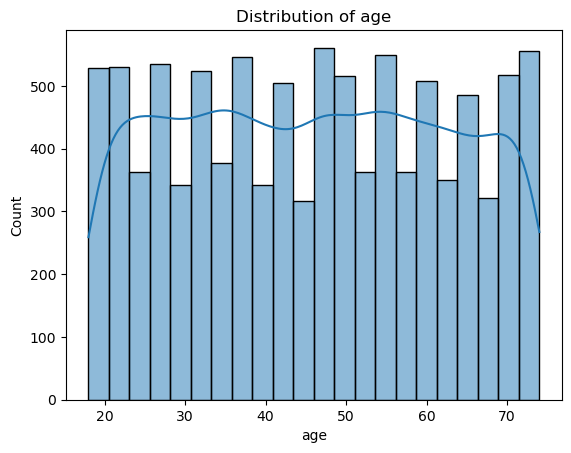

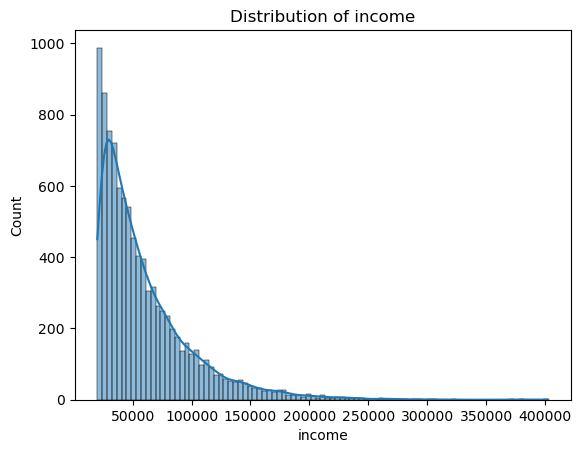

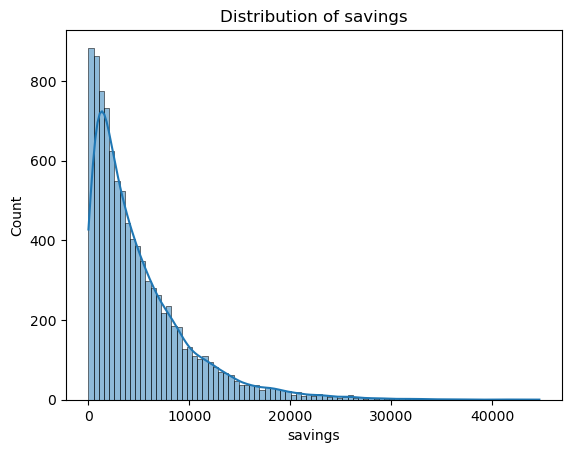

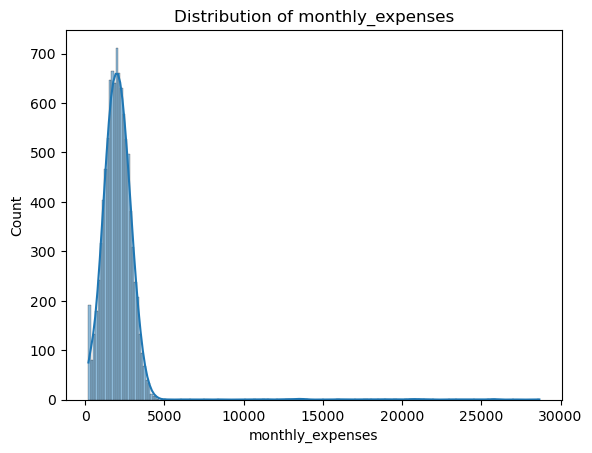

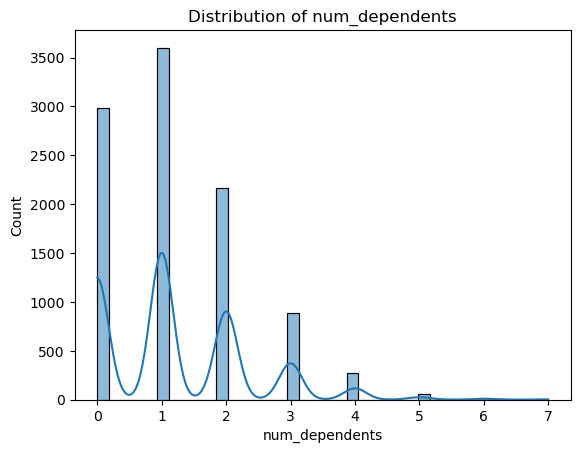

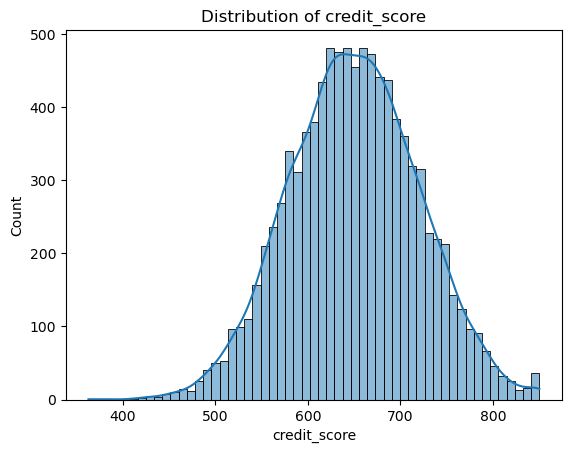

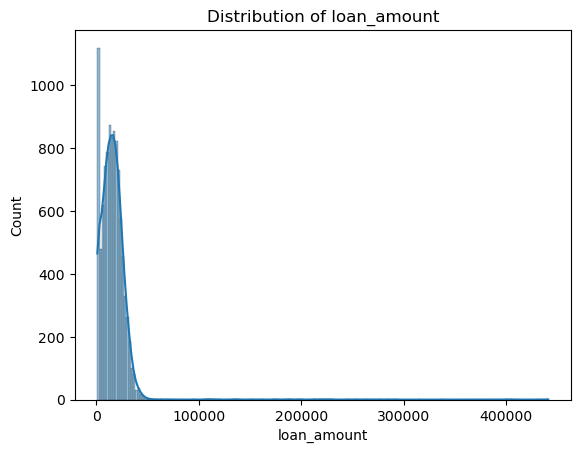

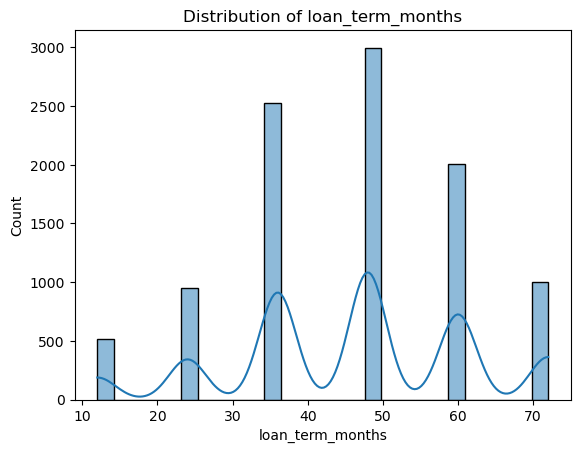

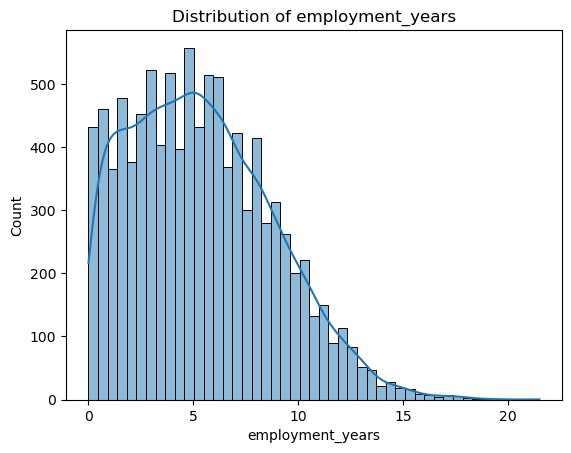

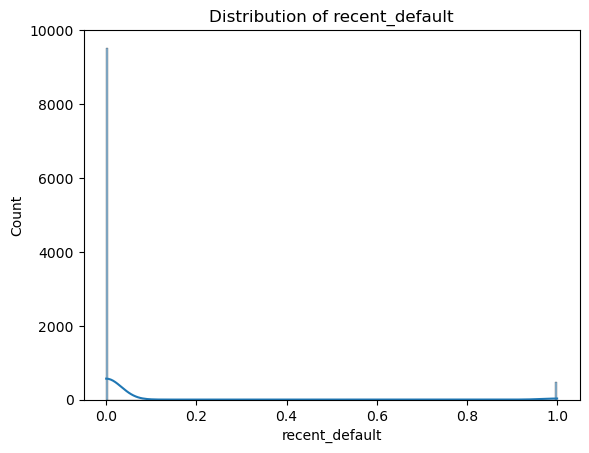

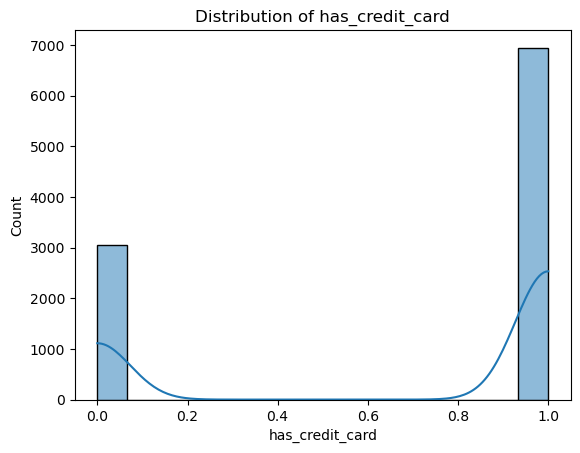

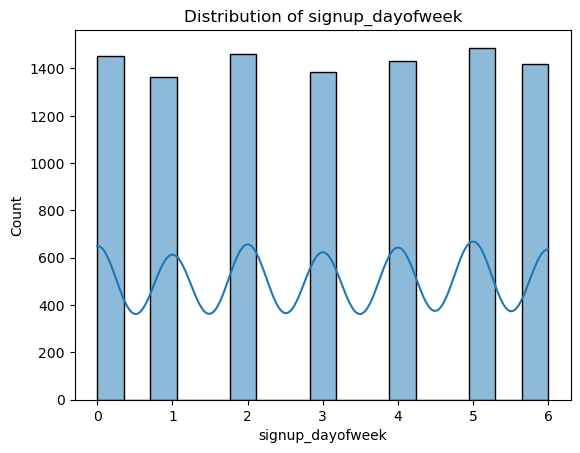

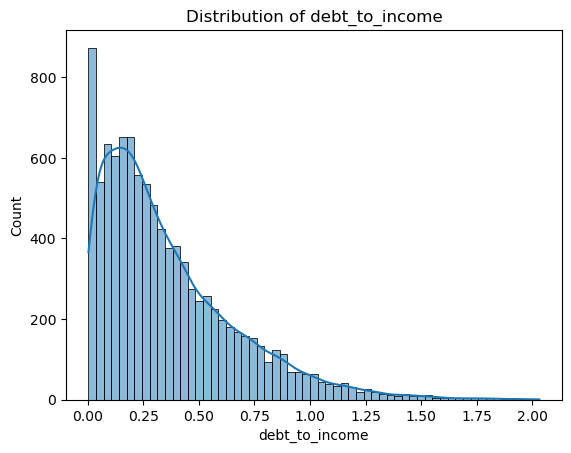

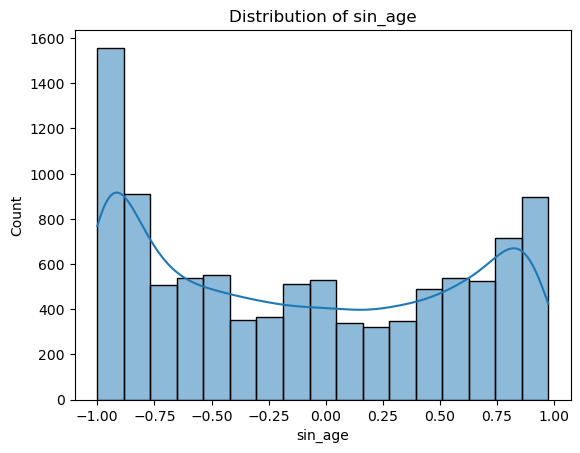

In [27]:
num_cols = ['age', 'income', 'savings', 'monthly_expenses', 'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months', 'employment_years', 'recent_default', 'has_credit_card', 'signup_dayofweek', 'debt_to_income', 'sin_age']
for col in num_cols:
    sns.histplot(x=col, data=df, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='credit_score', ylabel='Count'>

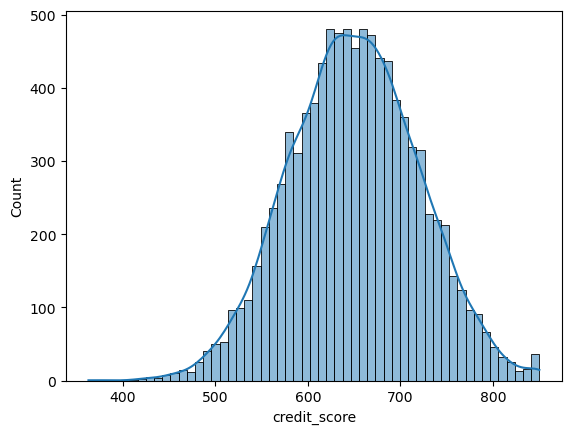

In [28]:
sns.histplot(x="credit_score", data=df, kde=True)

In [29]:
for col in num_cols:
    print(col,df[col].skew())

age 0.017032930534317835
income 1.9817283110473078
savings 2.0173309448057952
monthly_expenses 9.137278588570627
num_dependents 0.9415401831136688
credit_score 0.011038873299395433
loan_amount 11.21603130751375
loan_term_months -0.19759142055630802
employment_years 0.528900293545387
recent_default 4.2815199320526105
has_credit_card -0.8461783909328783
signup_dayofweek -0.017084940595655233
debt_to_income 1.3541285927493893
sin_age 0.13670033872462267


### **Distribution analysis**

credit_score is normally distributed as per histplot

most features are mildly skewed, while income, savings, monthly_expenses, loan_amount, recent_default, and debt_to_income show notable right skewness.

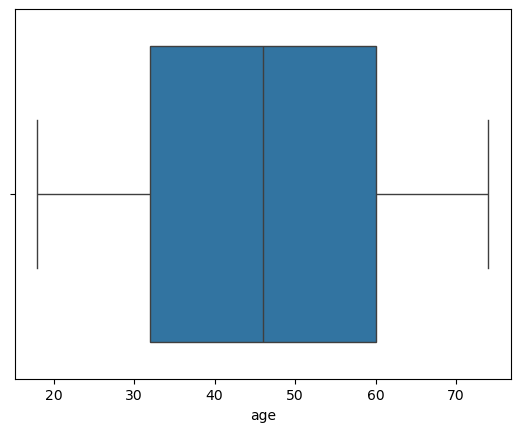

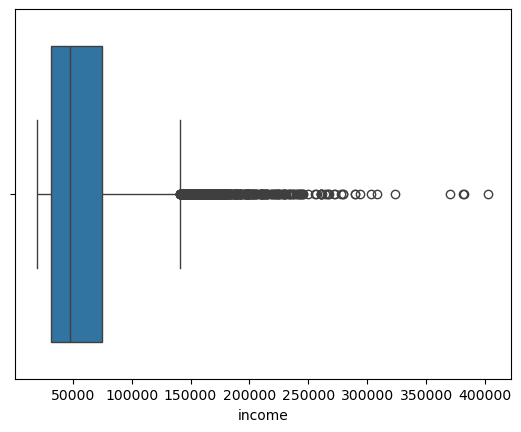

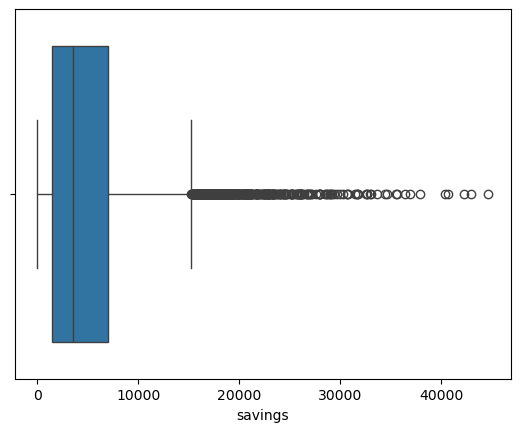

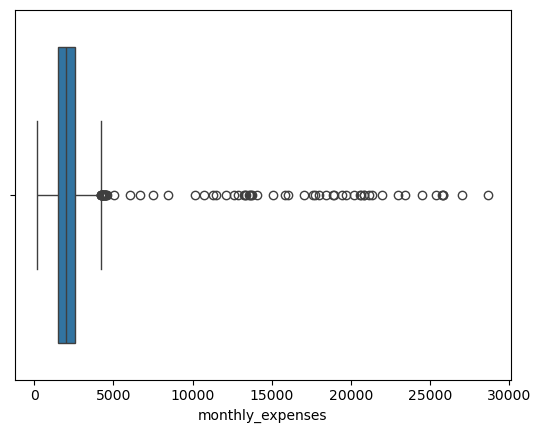

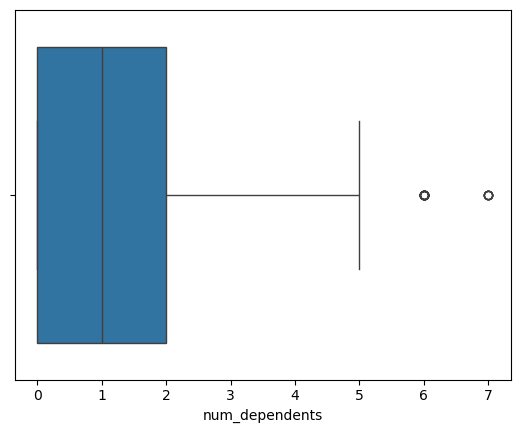

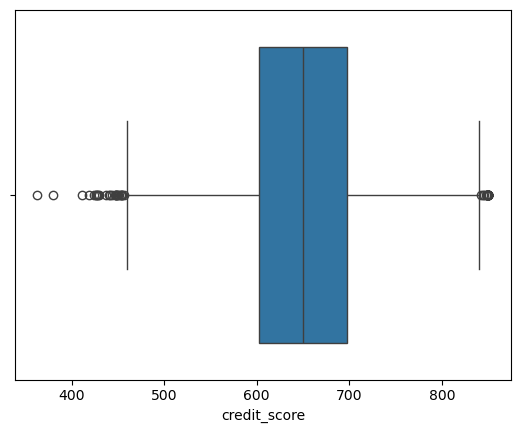

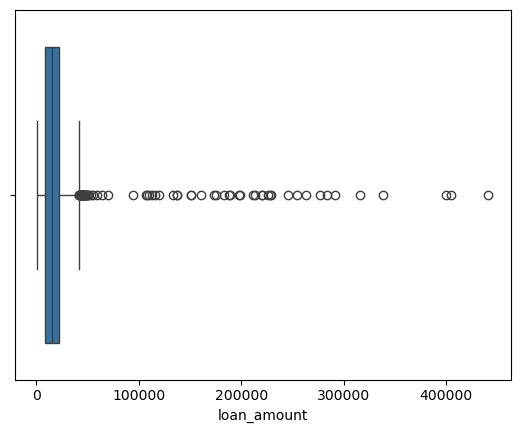

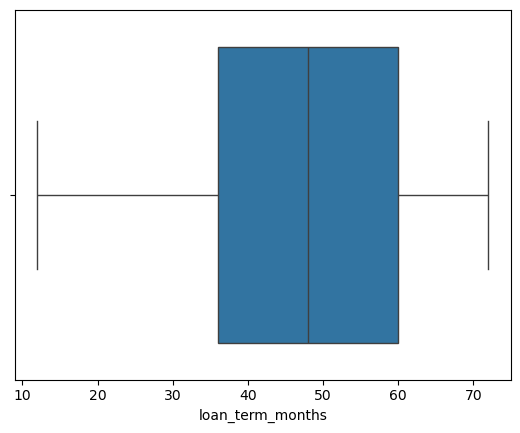

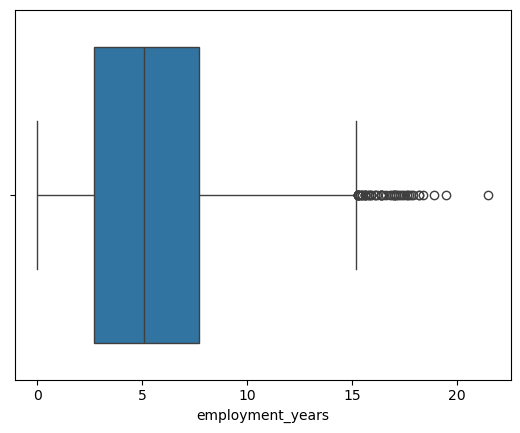

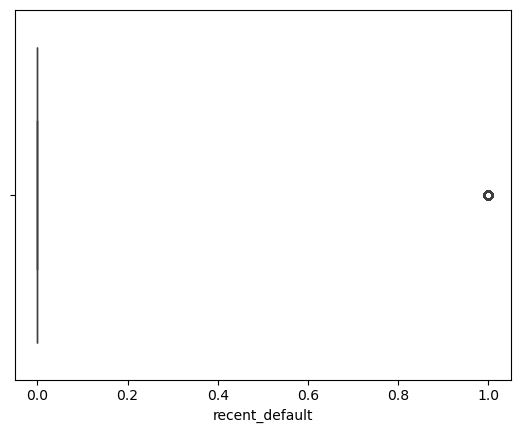

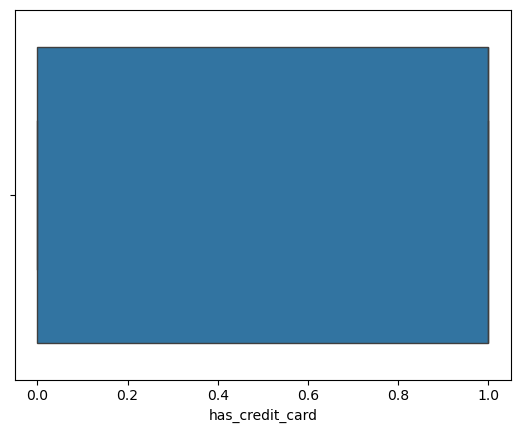

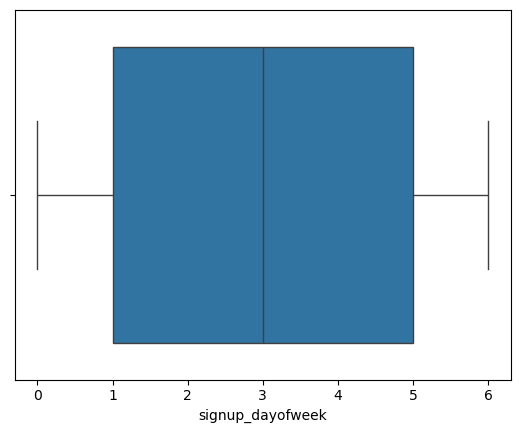

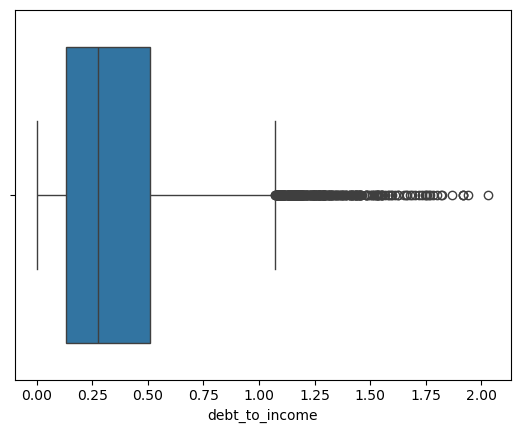

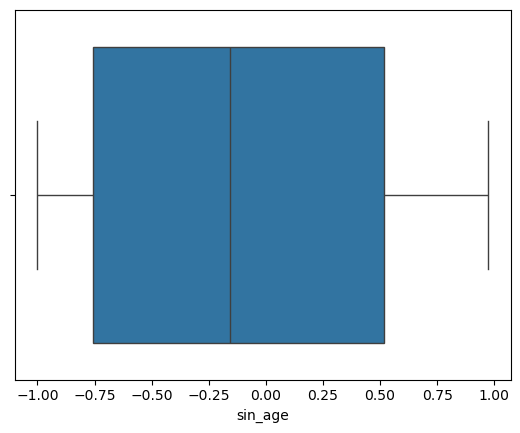

In [30]:
for col in num_cols:
    sns.boxplot(x=col, data=df)
    plt.show()

### **Outlier Analysis**

by observing the above boxplots potential outliers were observed in **income, savings, monthly_expenses, loan_amount, debt_to_income, employment_years, and num_dependents.**

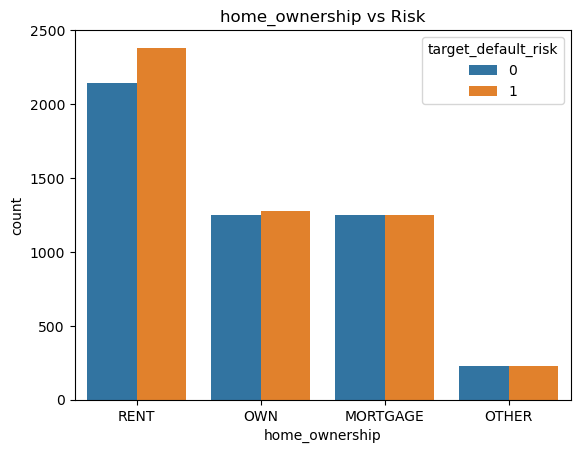

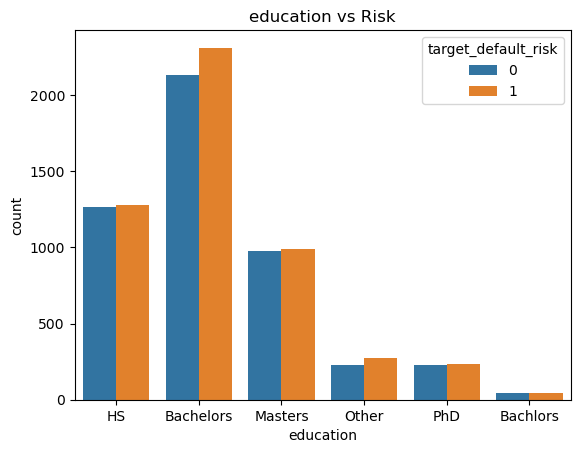

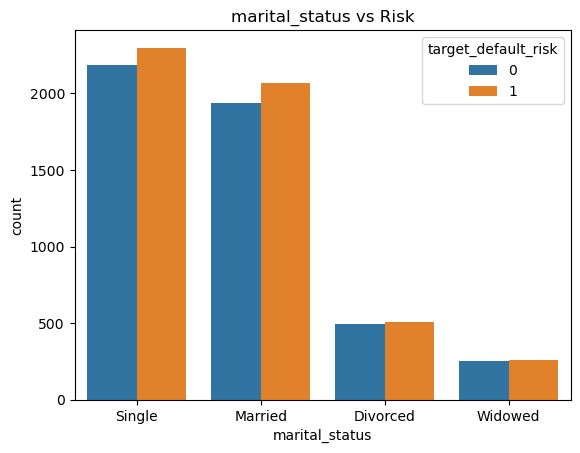

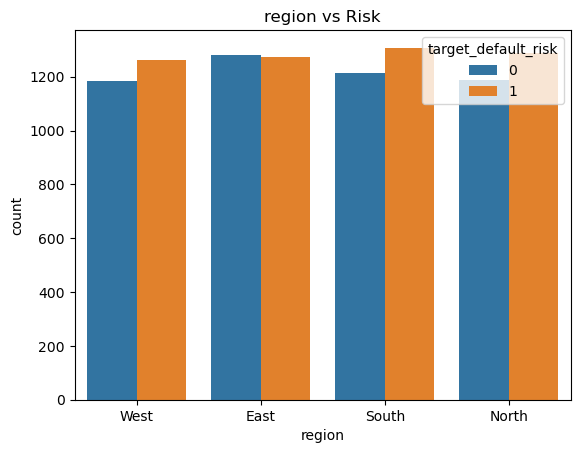

In [31]:
catg_cols = ['home_ownership','education','marital_status','region']
for col in catg_cols:
    sns.countplot(data=df,x=col,hue='target_default_risk')
    plt.title(f'{col} vs Risk')
    plt.show()

In [32]:
df['recent_default'].value_counts()

recent_default
0    9530
1     470
Name: count, dtype: int64

In [33]:
df['has_credit_card'].value_counts()

has_credit_card
1    6948
0    3052
Name: count, dtype: int64

In [34]:
df['target_default_risk'].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

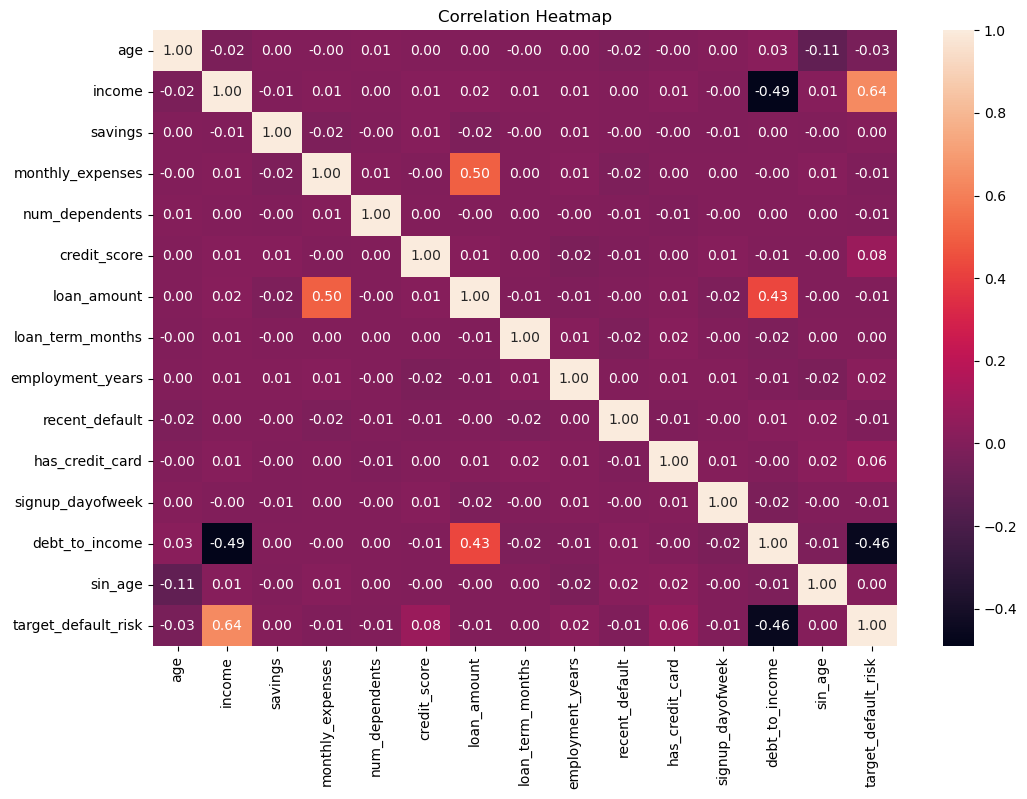

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [36]:
df.select_dtypes('number').corr()['target_default_risk'].sort_values()

debt_to_income        -0.458263
age                   -0.032432
monthly_expenses      -0.009883
recent_default        -0.007756
num_dependents        -0.006364
signup_dayofweek      -0.006197
loan_amount           -0.005924
loan_term_months       0.001930
savings                0.004065
sin_age                0.004951
employment_years       0.023547
has_credit_card        0.058778
credit_score           0.080062
income                 0.637879
target_default_risk    1.000000
Name: target_default_risk, dtype: float64

### **Correlation analysis**
**income(0.64)** is highly correlated to traget_default_risk column and **debit_to_income(-0.46)** is second highest correlated to target_default_risK

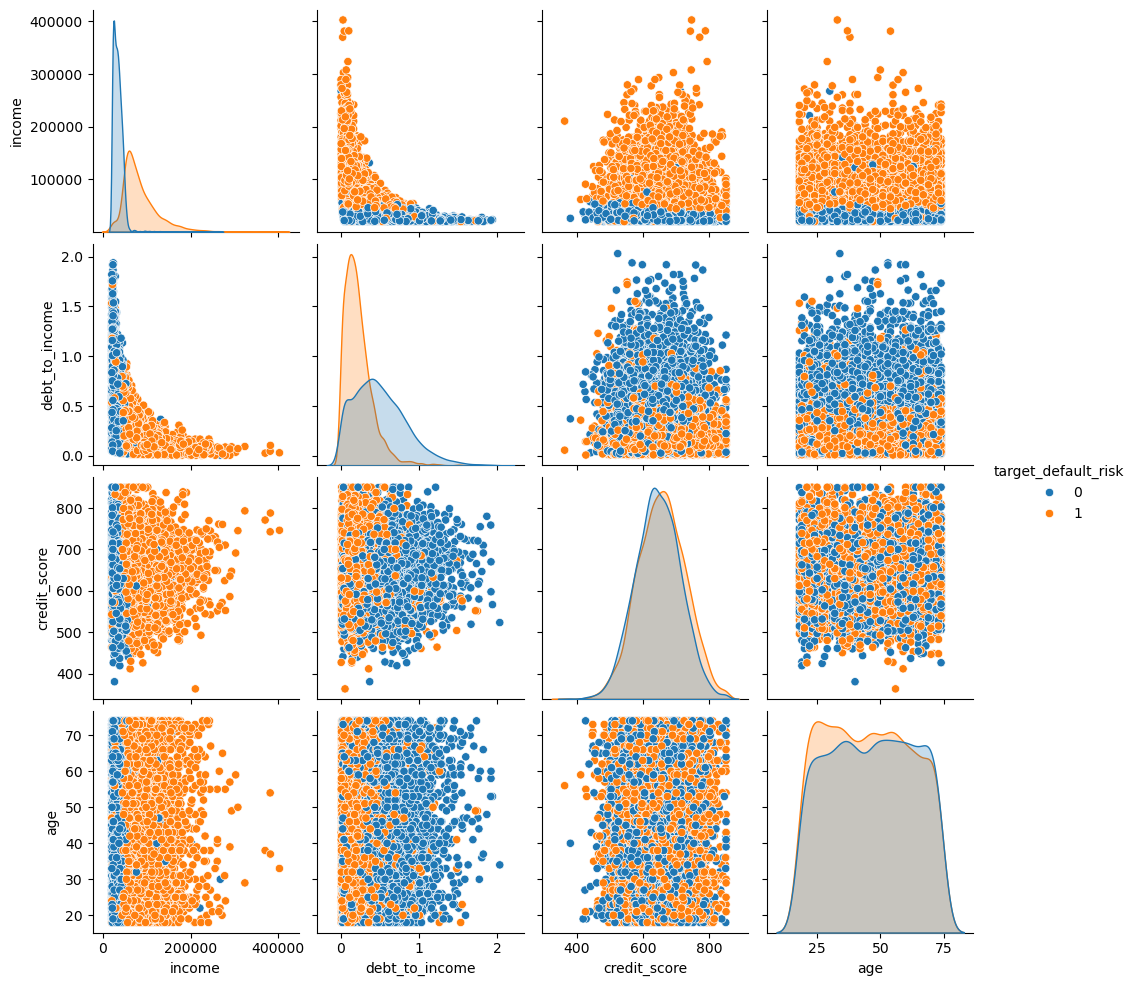

In [37]:
sns.pairplot(df[['income', 'debt_to_income', 'credit_score', 'age', 'target_default_risk']], hue='target_default_risk')
plt.show()

### **Pairplot analysis**
Consistent with the correlation results, income and debt_to_income show the clearest
separation between Default and No Default, while credit_score and age overlap heavily
between the two classes.

In [38]:
df['target_default_risk'].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

**target column is balanced**

### **Phase -1 Exploratory Data Analysis (EDA) and data understanding completed**
---
**Summary :**

- The dataset contains 10000 rows and 21 features
- In 21 colums data set contains **15 Numerical columns and 4 Categorical columns**
- There are **zero** duplicate values
- Missing values are present in **income-318, savings-311, monthly_expenses-325, and credit_score-326**
- Checked unique values and in Education contains **Bachelors** and **Bachlors** so replace it with **Bachelors**
- Analyised distribution of columns and **credit_score** is approximately normally distributed as per histplot
- Most features are mildly skewed, while **income, savings, monthly_expenses, loan_amount, recent_default, and debt_to_income** show notable right skewness.
- outliers were observed in **income, savings, monthly_expenses, loan_amount, debt_to_income, employment_years, and num_dependents.**
- **income** is highly correlated to traget_default_risk column
- Target column is nearly balanced so no need to perform SMOTE 

---

### **PHASE-2 Data Preprocessing**
---

### **Handling outliers**

In [39]:
cols =  ['income','savings', 'monthly_expenses','loan_amount','debt_to_income','employment_years','num_dependents','credit_score']

In [40]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    iqr = Q3 - Q1
    lb = Q1 - 1.5*iqr
    ub = Q3 +1.5*iqr

    outliers = df[(df[col]<lb) | (df[col]>ub)]
    print(f"{col}: {len(outliers)} outliers")


income: 479 outliers
savings: 472 outliers
monthly_expenses: 70 outliers
loan_amount: 89 outliers
debt_to_income: 318 outliers
employment_years: 51 outliers
num_dependents: 24 outliers
credit_score: 62 outliers


In [41]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    iqr = Q3 - Q1
    lb = Q1 - 1.5*iqr
    ub = Q3 +1.5*iqr

    outliers = df[(df[col]<lb) | (df[col]>ub)]

    df[col] = df[col].clip(lower=lb, upper=ub)

In [42]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    iqr = Q3 - Q1
    lb = Q1 - 1.5*iqr
    ub = Q3 +1.5*iqr

    outliers = df[(df[col]<lb) | (df[col]>ub)]

    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
savings: 0 outliers
monthly_expenses: 0 outliers
loan_amount: 0 outliers
debt_to_income: 0 outliers
employment_years: 0 outliers
num_dependents: 0 outliers
credit_score: 0 outliers


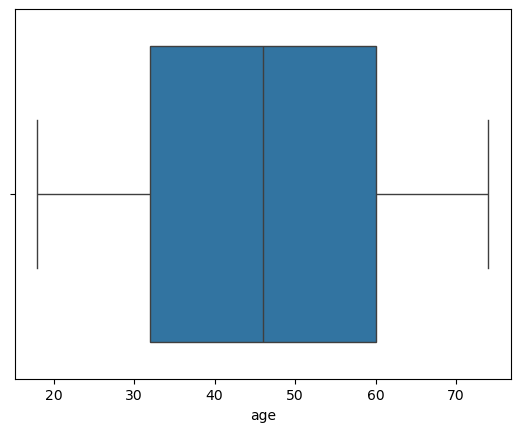

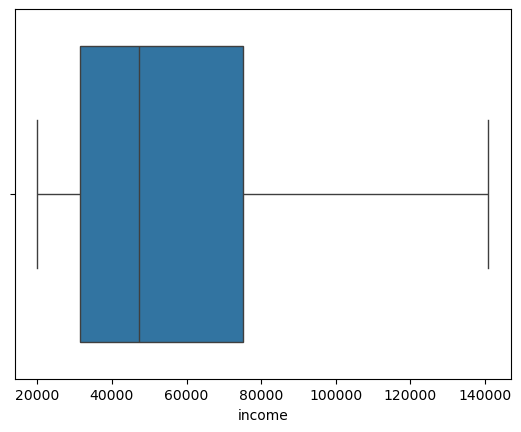

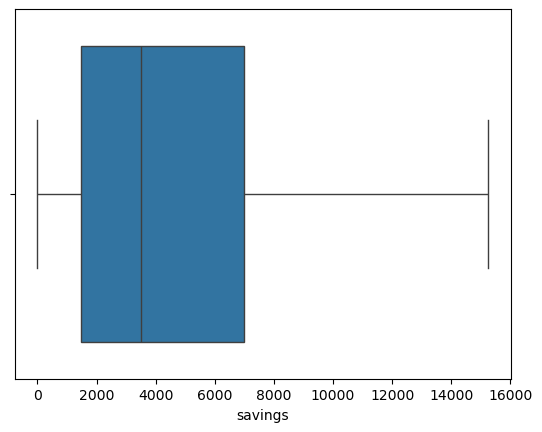

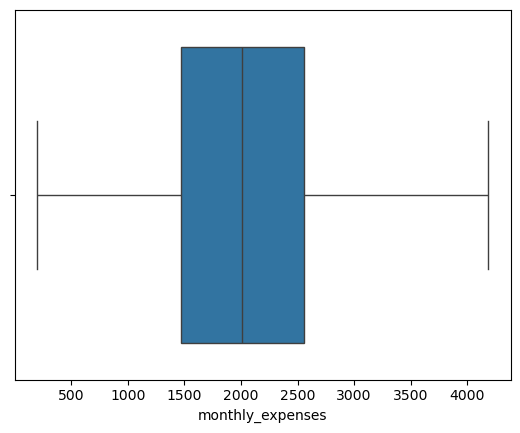

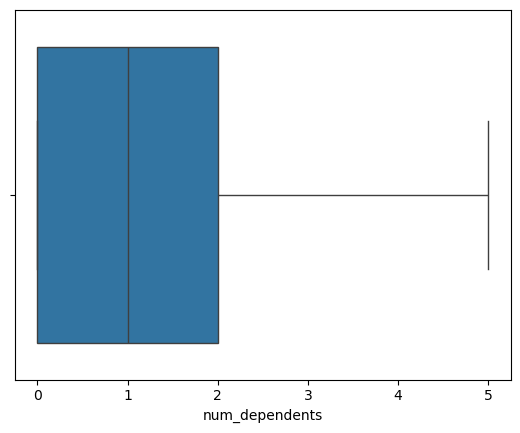

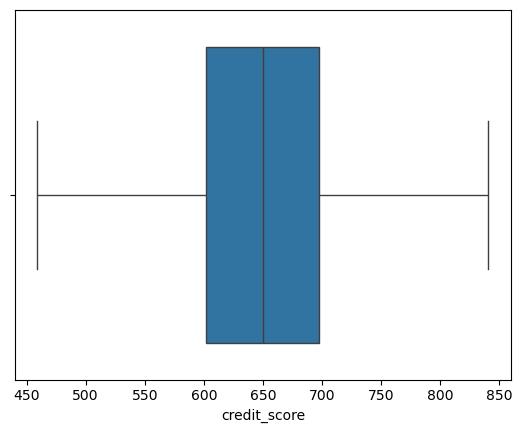

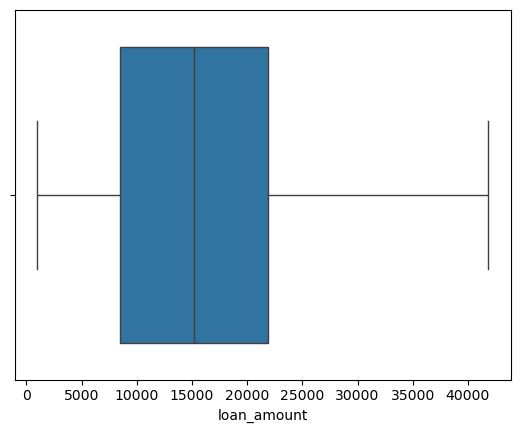

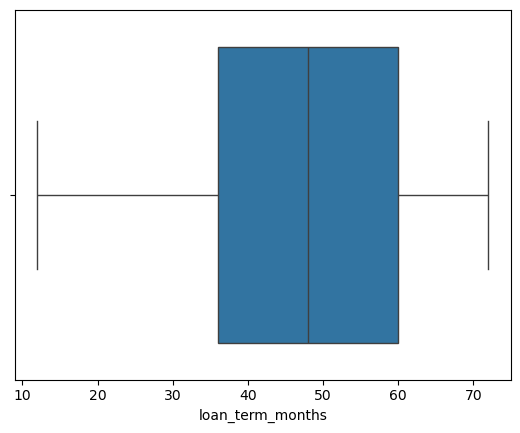

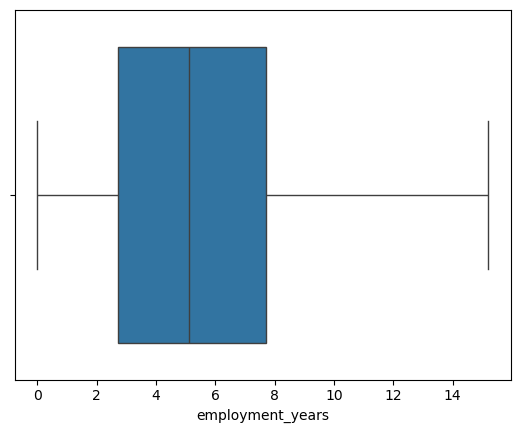

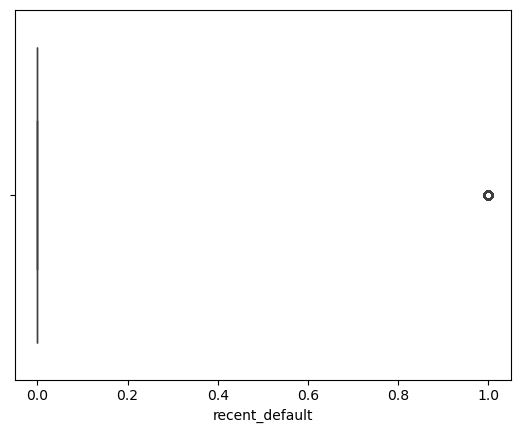

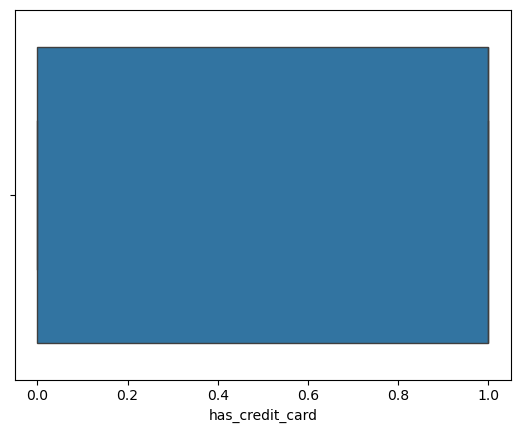

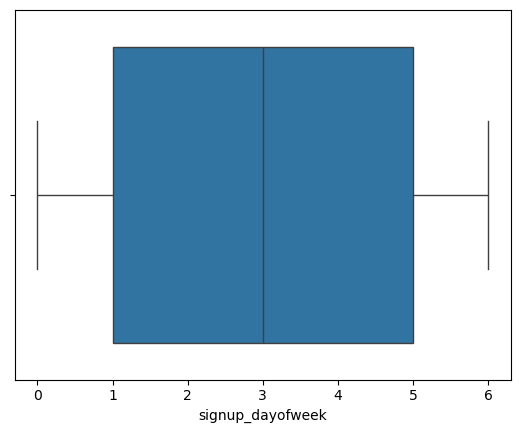

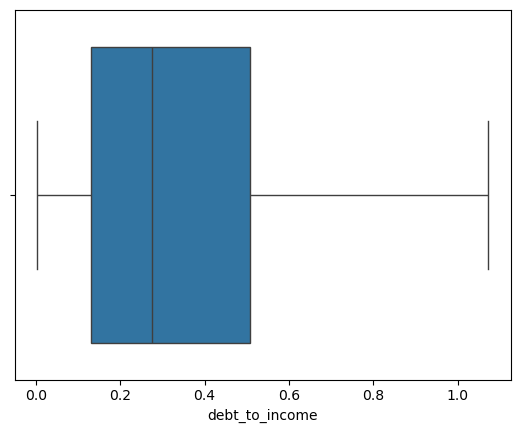

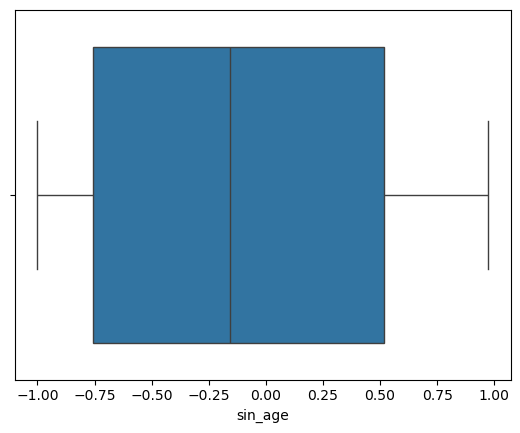

In [43]:
for col in num_cols:
    sns.boxplot(x=col, data=df)
    plt.show()

### **OUTLIER HANDLING**
- IQR analysis identified outliers in income (479), savings (472), monthly_expenses (70), loan_amount (89), debt_to_income (318), employment_years (51), num_dependents (24), and credit_score (62), which were capped at the lower and upper IQR bounds.

---

### **HANDLING MISSING VALUES**

In [44]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [45]:
mcol = ['income', 'savings', 'monthly_expenses', 'credit_score'] 
for col in mcol:
    print(df[col].skew())

1.068309635218455
1.062349540765038
0.10336798649904684
0.025307972614616238


In [46]:
df['income'] = df['income'].fillna(df['income'].median())
df['savings'] = df['savings'].fillna(df['savings'].median())
df['monthly_expenses'] = df['monthly_expenses'].fillna(df['monthly_expenses'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].mean())

In [47]:
df.isnull().sum()

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64

### **HANDLING MISSING VALUES**
---
- There are 1,280 missing values across four numerical features: income (318), savings (311), monthly_expenses (325), and credit_score (326).
- income,savings,monthly_expenses were imputed with median because these are mostly right skewed and credit_score is approximately skew is its imputed with mean
- Missing values are imputed after capping outliers 
---

### **Education contains Bachelors and Bachlor**

In [48]:
df['education'] = df['education'].replace({'Bachlors': 'Bachelors'})

In [49]:
df['education'].unique()

array(['HS', 'Bachelors', 'Masters', 'Other', 'PhD'], dtype=object)

### **Encoding and Feature Scaling**
---

- Encoding categorical columns using one-hot encoding and ordinal encoding
- Feature scaling using StandardScaler
- Using column transformers to perfom feature scaling and feature encoding

In [50]:
num_cols

['age',
 'income',
 'savings',
 'monthly_expenses',
 'num_dependents',
 'credit_score',
 'loan_amount',
 'loan_term_months',
 'employment_years',
 'recent_default',
 'has_credit_card',
 'signup_dayofweek',
 'debt_to_income',
 'sin_age']

In [51]:
catg_cols

['home_ownership', 'education', 'marital_status', 'region']

### **Spliting data into train_test_split**

In [52]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


### **Feature Creation**
---
- creating new feature that provide useful meaning for training


In [53]:
df['monthly_installment_ratio'] = (df['loan_amount'] / df['loan_term_months']) / (df['income'] / 12)
df['signup_date'] = pd.to_datetime(df['signup_date'])

df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month
df['days_since_signup'] = (pd.Timestamp.today() - df['signup_date']).dt.days

df = df.drop(columns=['signup_date'])

In [54]:
x = df.drop(columns=['customer_id', 'target_default_risk'])
y = df['target_default_risk']

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2, random_state = 42 ,stratify=y)

In [56]:
x

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,home_ownership,...,region,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,monthly_installment_ratio,signup_year,signup_month,days_since_signup
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,RENT,...,West,1,1,6,0.404,0.141120,0.101012,2020,7,2267
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,RENT,...,East,0,0,2,0.066,0.808496,0.022057,2018,10,2908
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,OWN,...,East,0,1,2,0.325,0.494113,0.054140,2018,5,3034
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,OWN,...,South,0,1,6,0.719,-0.982453,0.239607,2018,4,3072
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,MORTGAGE,...,West,0,0,1,0.324,0.898708,0.107876,2019,12,2482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,RENT,...,East,0,1,3,0.699,-0.772764,0.174630,2020,2,2396
9996,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,RENT,...,North,0,0,3,0.435,-0.958924,0.086940,2018,8,2949
9997,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,OTHER,...,West,0,0,4,0.719,-0.916166,0.143785,2019,1,2801
9998,44,38273.0,15251.0,1060.0,2,653.277645,1000.0,24,11.4,MORTGAGE,...,North,0,1,6,0.026,-0.951602,0.013064,2019,8,2603


In [57]:
df[catg_cols].sample(5)

,home_ownership,education,marital_status,region
4135,OWN,Masters,Married,South
375,RENT,HS,Single,North
7814,OWN,HS,Married,North
1896,RENT,Bachelors,Single,West
7708,RENT,Masters,Single,East


### **Encoding Categorical columns**
---
- **Education** is ordinal so we can use ordinal-encoder
- **home_ownership, marital_status, region** can be encoded using One-hot encoding


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

In [59]:
transformer = ColumnTransformer(transformers=[
    ("tnf1", OrdinalEncoder(categories=[['Other','HS', 'Bachelors', 'Masters', 'PhD']]), ['education']),
    ("tnf2", OneHotEncoder(sparse_output=False, drop='first'), ['home_ownership', 'marital_status', 'region'])
], remainder='passthrough')

In [60]:
transformer.set_output(transform='pandas')
transformer.fit(x_train)

x_train_encoded = transformer.transform(x_train)
x_test_encoded = transformer.transform(x_test)

print(x_train_encoded.shape)
print(x_test_encoded.shape)

(8000, 28)
(2000, 28)


In [61]:
x_train_encoded.sample(15)

,tnf1__education,tnf2__home_ownership_OTHER,tnf2__home_ownership_OWN,tnf2__home_ownership_RENT,tnf2__marital_status_Married,tnf2__marital_status_Single,tnf2__marital_status_Widowed,tnf2__region_North,tnf2__region_South,tnf2__region_West,...,remainder__employment_years,remainder__recent_default,remainder__has_credit_card,remainder__signup_dayofweek,remainder__debt_to_income,remainder__sin_age,remainder__monthly_installment_ratio,remainder__signup_year,remainder__signup_month,remainder__days_since_signup
2131,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,8.1,0,1,3,0.458,0.215120,0.091662,2021,1,2060
4556,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.5,0,1,3,0.845,-0.442520,0.169066,2018,11,2872
141,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,8.1,0,0,1,0.352,-0.279415,0.117188,2019,1,2818
6567,2.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,5.7,0,1,2,0.145,-0.925815,0.029087,2018,8,2957
2224,2.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.2,0,0,2,0.162,-0.631267,0.032363,2023,1,1340
1802,2.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,10.2,0,0,6,0.428,-0.442520,0.085649,2020,3,2379
1766,3.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.4,0,1,0,0.092,-0.442520,0.018475,2020,7,2245
1820,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,2.5,0,0,4,0.095,0.016814,0.015815,2021,9,1821
4050,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,4.2,0,0,1,0.012,0.311541,0.006347,2019,1,2818
6651,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.8,0,1,5,0.343,0.898708,0.068503,2020,12,2100


In [62]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk,monthly_installment_ratio,signup_year,signup_month,days_since_signup
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,1,1,6,0.404,0.141120,1,0.101012,2020,7,2267
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,0,0,2,0.066,0.808496,1,0.022057,2018,10,2908
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,0,1,2,0.325,0.494113,0,0.054140,2018,5,3034
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,0,1,6,0.719,-0.982453,0,0.239607,2018,4,3072
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,0,0,1,0.324,0.898708,1,0.107876,2019,12,2482


In [63]:
df.dtypes

customer_id                   object
age                            int64
income                       float64
savings                      float64
monthly_expenses             float64
num_dependents                 int64
credit_score                 float64
loan_amount                  float64
loan_term_months               int64
employment_years             float64
home_ownership                object
education                     object
marital_status                object
region                        object
recent_default                 int64
has_credit_card                int64
signup_dayofweek               int64
debt_to_income               float64
sin_age                      float64
target_default_risk            int64
monthly_installment_ratio    float64
signup_year                    int32
signup_month                   int32
days_since_signup              int64
dtype: object

In [64]:
catg_cols

['home_ownership', 'education', 'marital_status', 'region']

In [65]:
x_train_encoded.dtypes

tnf1__education                         float64
tnf2__home_ownership_OTHER              float64
tnf2__home_ownership_OWN                float64
tnf2__home_ownership_RENT               float64
tnf2__marital_status_Married            float64
tnf2__marital_status_Single             float64
tnf2__marital_status_Widowed            float64
tnf2__region_North                      float64
tnf2__region_South                      float64
tnf2__region_West                       float64
remainder__age                            int64
remainder__income                       float64
remainder__savings                      float64
remainder__monthly_expenses             float64
remainder__num_dependents                 int64
remainder__credit_score                 float64
remainder__loan_amount                  float64
remainder__loan_term_months               int64
remainder__employment_years             float64
remainder__recent_default                 int64
remainder__has_credit_card              

### **Encoding Categorical columns completed**
---
- **Education** is encoded using ordinal-encoder
- **home_ownership, marital_status, region** is encoded using one-hot encoding
- **signup date** is dropped and further will create features using signup date like no of days till signed up

# **Feature scaling using StandardScaler**
---

In [66]:
num_cols = [
    'remainder__age',
    'remainder__income',
    'remainder__savings',
    'remainder__monthly_expenses',
    'remainder__num_dependents',
    'remainder__credit_score',
    'remainder__loan_amount',
    'remainder__loan_term_months',
    'remainder__employment_years',
    'remainder__signup_dayofweek',
    'remainder__debt_to_income'
]

x_train_encoded[num_cols].sample(10)

,remainder__age,remainder__income,remainder__savings,remainder__monthly_expenses,remainder__num_dependents,remainder__credit_score,remainder__loan_amount,remainder__loan_term_months,remainder__employment_years,remainder__signup_dayofweek,remainder__debt_to_income
4326,19,38796.0,1885.0,3180.0,2,664.356733,13868.0,48,3.3,1,0.357
1022,54,73463.0,979.0,267.0,3,591.383082,21969.0,36,4.3,4,0.299
285,35,82774.0,6797.0,1870.0,3,602.418916,24027.0,48,7.6,1,0.290
3109,74,21127.0,339.0,1283.0,1,726.867131,8229.0,48,14.1,4,0.389
7613,54,47839.0,3845.0,2105.0,1,518.361447,18849.0,60,6.4,2,0.394
9707,58,47301.5,4660.0,1274.0,0,743.255772,1000.0,72,3.6,6,0.018
7021,21,91057.0,8149.0,2307.0,1,459.168588,12799.0,36,3.9,1,0.141
6187,33,47773.0,3432.0,1237.0,2,687.576693,28157.0,48,2.2,6,0.589
1855,64,21803.0,1262.0,1536.0,0,672.865613,17631.0,60,7.7,3,0.809
2330,37,24739.0,5639.0,2068.0,2,679.696587,13052.0,60,2.9,5,0.528


In [67]:
print(x_train_encoded.shape)
x_test_encoded.shape

(8000, 28)


(2000, 28)

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
x_train_encoded.dtypes

tnf1__education                         float64
tnf2__home_ownership_OTHER              float64
tnf2__home_ownership_OWN                float64
tnf2__home_ownership_RENT               float64
tnf2__marital_status_Married            float64
tnf2__marital_status_Single             float64
tnf2__marital_status_Widowed            float64
tnf2__region_North                      float64
tnf2__region_South                      float64
tnf2__region_West                       float64
remainder__age                            int64
remainder__income                       float64
remainder__savings                      float64
remainder__monthly_expenses             float64
remainder__num_dependents                 int64
remainder__credit_score                 float64
remainder__loan_amount                  float64
remainder__loan_term_months               int64
remainder__employment_years             float64
remainder__recent_default                 int64
remainder__has_credit_card              

In [70]:
#convert np arrays to data frames
x_train_encoded = pd.DataFrame(
    x_train_encoded,
    columns=transformer.get_feature_names_out()
)

x_test_encoded = pd.DataFrame(
    x_test_encoded,
    columns=transformer.get_feature_names_out()
)

In [71]:
num_cols = [
    'remainder__age', 'remainder__income', 'remainder__savings',
    'remainder__monthly_expenses', 'remainder__num_dependents',
    'remainder__credit_score', 'remainder__loan_amount',
    'remainder__loan_term_months', 'remainder__employment_years',
    'remainder__signup_dayofweek', 'remainder__debt_to_income',
    'remainder__monthly_installment_ratio', 'remainder__signup_year',
    'remainder__signup_month', 'remainder__days_since_signup'
]

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_encoded[num_cols] = scaler.fit_transform(x_train_encoded[num_cols])
x_test_encoded[num_cols] = scaler.transform(x_test_encoded[num_cols])

In [73]:
x_train_encoded[num_cols].describe()

,remainder__age,remainder__income,remainder__savings,remainder__monthly_expenses,remainder__num_dependents,remainder__credit_score,remainder__loan_amount,remainder__loan_term_months,remainder__employment_years,remainder__signup_dayofweek,remainder__debt_to_income,remainder__monthly_installment_ratio,remainder__signup_year,remainder__signup_month,remainder__days_since_signup
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,-8.126833e-17,5.329071e-18,-1.083578e-16,-2.842171e-17,-6.128431e-17,-1.555200e-15,-4.085621e-17,-4.618528e-17,-1.776357e-17,4.463097e-17,1.629807e-16,-2.220446e-17,-2.977529e-14,-5.329071e-17,-1.612044e-16
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-1.683513e+00,-1.131099e+00,-1.137918e+00,-2.323016e+00,-1.098183e+00,-2.774243e+00,-1.552858e+00,-2.166678e+00,-1.592941e+00,-1.492934e+00,-1.234678e+00,-8.663398e-01,-1.424149e+00,-1.509352e+00,-1.733563e+00
25%,-8.357043e-01,-7.773033e-01,-7.764813e-01,-6.641237e-01,-1.098183e+00,-6.697809e-01,-7.525876e-01,-6.184979e-01,-7.955329e-01,-9.946040e-01,-7.822324e-01,-6.032507e-01,-7.950037e-01,-9.313333e-01,-8.663037e-01
50%,1.210398e-02,-3.104349e-01,-2.912796e-01,-1.003880e-02,-1.904062e-01,6.142970e-03,-4.907845e-02,1.555921e-01,-8.672553e-02,2.055610e-03,-2.763484e-01,-2.887956e-01,-1.658584e-01,-6.430463e-02,-1.812420e-02
75%,8.599123e-01,5.000617e-01,4.956533e-01,6.648463e-01,7.173709e-01,6.573418e-01,6.690971e-01,9.296821e-01,6.811491e-01,9.987152e-01,5.537287e-01,2.547984e-01,1.092432e+00,8.027241e-01,8.699492e-01
max,1.707721e+00,2.504975e+00,2.552301e+00,2.779102e+00,3.440702e+00,2.777091e+00,2.811990e+00,1.703772e+00,2.896172e+00,1.497045e+00,2.570139e+00,1.128558e+01,1.721577e+00,1.669753e+00,1.733739e+00


### **Feature Scaling using StandardScaler**
---
- Scaled numerical features using StandardScaler
- converted encoded x_train and x_test from numpy to dataframe
- now train_test split looks like **x_encoded_train and x_encoded_test** **|** **y_train and y_test**
---

### **PHASE-2 Data Preprocessing Completed**
---
### **Summary**
- I have identified outliers in **income (479), savings (472), monthly_expenses (70), loan_amount (89), debt_to_income (318), employment_years (51), num_dependents (24), and credit_score (62)**, which were **capped** at the **lower and upper IQR bounds**
- There are **1,280 missing values** across four numerical features **income, savings, monthly_expenses** were imputed with **median** because these are **mostly right skewed** and **credit_score** is approximately skew is its **imputed with mean**
- Education contains **Bachelors and Bachlor**
- Created new feaure **monthly_installment_ratio** to add value to train the model
- Splited the data into **train_test_split**
- Dropped **customer_id and signup_date** from the current features
- feature encoded **education was ordinal-encoded**, **home_ownership, marital_status, and region were one-hot encoded**
- Scaled numerical features using **StandardScaler**
- now train_test split looks like **x_train_encoded and x_test_encoded** **|** **y_train and y_test**


---

### **PHASE - 3 Training Baseline Models**
---
1. **Logistic Regression**
2. **Decision Tree**
3. **Support Vector Machine (SVM)**
4. **Random Forest**
5. **XGBoost**

In [74]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [75]:
rf_model = RandomForestClassifier()
lr_model = LogisticRegression()
svm_model = SVC()
dt_model = DecisionTreeClassifier()
xg_model = XGBClassifier()

In [77]:
rf_model.fit(x_train_encoded,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
lr_model.fit(x_train_encoded,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [63]:
svm_model.fit(x_train_encoded,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [64]:
dt_model.fit(x_train_encoded,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
xg_model.fit(x_train_encoded,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [78]:
y_pred_rf = rf_model.predict(x_test_encoded)

In [67]:
y_pred_lr = lr_model.predict(x_test_encoded)

In [68]:
y_pred_svm = svm_model.predict(x_test_encoded)

In [69]:
y_pred_dt = dt_model.predict(x_test_encoded)

In [70]:
y_pred_xg = xg_model.predict(x_test_encoded)

In [80]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix 

In [81]:
accuracy_score(y_test,y_pred_rf)

0.9435

In [73]:
accuracy_score(y_test,y_pred_lr)

0.9385

In [74]:
accuracy_score(y_test,y_pred_svm)

0.938

In [75]:
accuracy_score(y_test,y_pred_dt)

0.9215

In [76]:
accuracy_score(y_test,y_pred_xg)

0.956

In [77]:
predictions = [y_pred_rf, y_pred_dt, y_pred_xg, y_pred_lr, y_pred_svm]
print("PRECISION-Score:")
for y_pred in predictions:
    print(precision_score(y_test, y_pred))

PRECISION-Score:
0.9575757575757575
0.9198067632850242
0.9634387351778656
0.9611848825331971
0.9620901639344263


In [78]:
print("RECALL-Score:")
for y_pred in predictions:
    print(recall_score(y_test, y_pred))

RECALL-Score:
0.9239766081871345
0.9278752436647173
0.9502923976608187
0.9171539961013645
0.9152046783625731


In [79]:
print("F1-Score:")
for y_pred in predictions:
    print(f1_score(y_test, y_pred))

F1-Score:
0.9404761904761905
0.9238233867054828
0.956820412168793
0.9386533665835411
0.938061938061938


In [80]:
print("CONFUSION_MATRIX:")
for y_pred in predictions:
    print(confusion_matrix(y_test, y_pred))

CONFUSION_MATRIX:
[[932  42]
 [ 78 948]]
[[891  83]
 [ 74 952]]
[[937  37]
 [ 51 975]]
[[936  38]
 [ 85 941]]
[[937  37]
 [ 87 939]]


### **PHASE-3 Training Baseline Models Completed**
---
- Trained **Logistic Regression, Decision Tree, Support Vector Machine (SVM), Random Forest, XGBoost** models
- Achieved accuracy score of :-
- **93.85%** in Logistic Regression
- **92.1%** in Decision Tree
- **93.8%** in Support Vector Machine (SVM)
- **94.35%** in Random Forest
- **95.6%** in XGBoost

---

### **PHASE - 4 Hyperparameter Tuning**
---
- Tuning baseline models using GridsearchCV
- Importing StratifiedKFold for CV


In [81]:
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [82]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

### **SVM tuning**

In [83]:
param_grid ={
    'C' : [0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma' : ['scale','auto']}
grid = GridSearchCV(SVC(),param_grid,scoring = 'f1',cv=cv,n_jobs=-1,verbose=1)
grid.fit(x_train_encoded, y_train)
print(grid.best_params_)
grid.best_score_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


np.float64(0.9431987666091853)

In [84]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test_encoded)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.946


### **RANDOM FOREST Tuning**

In [85]:
rfm_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(), rfm_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(x_train_encoded, y_train)
print(rf_grid.best_params_)
print(rf_grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.9307088549600925


In [86]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(x_test_encoded)

print("Random_forest_tuned:",accuracy_score(y_test, y_pred_rf_tuned))

Random_forest_tuned: 0.941


### **DECISION TREE TUNING**

In [87]:
dt_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),dt_grid,scoring='f1',cv=cv,n_jobs=-1,verbose=1)
dt_grid_search.fit(x_train_encoded, y_train)

print(dt_grid_search.best_params_)
print(dt_grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.9382133540626489


In [88]:
best_dt = dt_grid_search.best_estimator_

y_pred_dt_tuned = best_dt.predict(x_test_encoded)
print("Tuned DT Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))


Tuned DT Accuracy: 0.934


### **LOGISTIC REGRESSION Tuning**

In [89]:
lr_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [500, 1000]
}

lr_grid_search = GridSearchCV(LogisticRegression(random_state=42),lr_grid,scoring='f1',cv=cv,n_jobs=-1,verbose=1)

lr_grid_search.fit(x_train_encoded, y_train)

print(lr_grid_search.best_params_)
print(lr_grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'}
0.9357417817253403


In [90]:
best_lr = lr_grid_search.best_estimator_

y_pred_lr_tuned = best_lr.predict(x_test_encoded)
print("Tuned LR Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))


Tuned LR Accuracy: 0.94


### **XGBOOST TUNING**

In [ ]:
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(XGBClassifier(random_state=42,eval_metric='logloss',n_jobs=1),xgb_grid,scoring='f1',cv=cv,n_jobs=-1,verbose=1)

xgb_grid_search.fit(x_train_encoded, y_train)

print(xgb_grid_search.best_params_)
print(xgb_grid_search.best_score_)

In [92]:
best_xgb = xgb_grid_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(x_test_encoded)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Tuned XGBoost F1:", f1_score(y_test, y_pred_xgb_tuned))

Tuned XGBoost Accuracy: 0.9595
Tuned XGBoost F1: 0.9602746444335458


### **PHASE-4 HyperParameter Tuning Completed**
---
### **Summary**
- Tuned models using GridSearchCV
- Accuracy increase from **93.85%** to **94%** in **Logistic Regression**
- Accuracy increase from **92.1%** to **93.4%** in **Decision Tree**
- Accuracy increase from **93.8%** to **94.60%** in **Support Vector Machine**
- Accuracy increased from **94.35%** to **94.1** in **Random Forest**
- Accuracy increase from **95.6%** to **95.95** in **XGBoost**
- Overall Hyperparameter tuning helped increase **accuracy_score**
---

### **OVERALL ASSIGNMENT REPORT**
---

- **Overall, While working on this assignment i gained valuable insights and hands on practical experince of performing Exploratary Data Analysis, Data preprocessing, Data cleaning, Feature scaling, Feature encoding, Feature creation, train_test_split, model training, model evaluation  , Hyperparameter tuning.**

- Dataset and understood data (shape,columns,info,dtypes,descibe,unique) and ploted box plots for observing outliers and ploted bar charts for observing class imbalance and observed correlation with target column
- The dataset had 1565 outliers in total in **income, savings, monthly_expenses, loan_amount, debt_to_income, employment_years, and num_dependents.**
- The dataset had 1280 missing values in total **income (318), savings (311), monthly_expenses (325), and credit_score (326)**
- income, saving, montly_expense were right skewed so i have used median to impute them and credit_score was fairly skewed so i have used mean
- Every categorical column was fairly balanced
- Categorical columns were encoded using **one-hot encoding and Ordinal encoding**.
- Numerical features were scaled using **StandardScaler** to reduce model prioritizing high numerical values
- Created new feaure **monthly_installment_ratio** using loan_amount and duration

- Trained baseline models **Logistic Regression, Decision Tree, Support Vector Machine (SVM), Random Forest, XGBoost**

- Achieved accuracy of - **93.85%** in Logistic Regression , **92.15%** in Decision Tree , **93.8%** in Support Vector Machine (SVM) , **94.35%** in Random Forest , **95.6%** in XGBoost

- Performed **Hyperparameter Tuning** on baseline models using **GridSearchCV** and achieve **minor accuracy score increase** in all models

- Marked and commented almost all cells for better insights and understanding

---

### **Conclusion**
---
- **Overall, this assignment helped me gain pratical and hands-on experience and pratice in complete machine learning end to end from Data understanding, analysis, preprocessing, model training, evaluation, hyperparameter tuning. The modles achieved overall strong accuracy score and **XGBOOST** achieved highest accuracy score of 95.95% after hyperparameter tuning.Hyperparameter tuning helped models to gain very minor increase in performance.**

---
**- Karthik tatineni**